# Getting started with `affectlens`

`affectlens` extracts **time-varying features** from video, audio, and music clips
— luminance, motion, loudness, spectral shape, and more — and gives you two ready
ways to use them: **predict human ratings**, or **relate the features to a
separately recorded signal** (a physiological or brain channel) with a lag search.

This notebook walks the whole pipeline on the public sample clips, with a plot at
each step. Setup (from the repo root):

```
pip install -e ".[notebook]"      # the library + matplotlib + jupyterlab
python scripts/fetch_samples.py   # download the linked public sample clips
```

The setup cell below will fetch the clips too if they are missing.

Everything here is also available from the command line; the last section maps each
step to its `affectlens ...` command.

In [1]:
%matplotlib inline
import subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# Find the repo root (the folder with pyproject.toml), regardless of where the
# notebook is launched from.
REPO = Path.cwd()
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
SAMPLES = REPO / "examples" / "samples"

# Fetch the linked public sample clips if they aren't here yet.
if not any(SAMPLES.glob("*.*")):
    subprocess.run([sys.executable, str(REPO / "scripts" / "fetch_samples.py")], check=True)

sorted(p.name for p in SAMPLES.glob("*.*"))

['city_short.mp4', 'elephants_dream.mp4', 'music_only.mp3', 'nature_short.mp4']

## 1. What's in the clips? — `inventory`

Before extracting anything, probe the folder: duration, resolution, frame rate, and
whether each clip carries video and/or audio. `affectlens` handles video, silent
video, and audio-only files (e.g. music) — the inventory tells you which is which.

In [2]:
from affectlens import clips as clips_mod

inv = clips_mod.inventory(SAMPLES)
pd.DataFrame([
    {"clip": c.name, "duration_s": round(c.duration_s, 1) if c.duration_s else None,
     "fps": c.fps, "video": c.has_video, "audio": c.has_audio}
    for c in inv
])

,clip,duration_s,fps,video,audio
0,city_short.mp4,20.3,29.97,True,True
1,elephants_dream.mp4,653.8,24.00,True,True
2,music_only.mp3,19.2,NaN,False,True
3,nature_short.mp4,30.4,30.00,True,True


## 2. Extract features — a *time × features* matrix

This is the core output, and the answer to "does it give one number per clip, or a
time course?" — **a time course**. Each clip becomes a matrix with **one row per
time bin** and **one column per feature**.

The bin width is a knob (`rating_interval_s`, or `--interval` on the CLI). We use
**half-second** bins here; underneath, the visual features are sampled at ~8
frames/s and audio at 40 ms windows, then aggregated into each bin (keeping `mean`,
`std`, and `max`, so a sharp within-bin event still shows up in the `*_max` column).

We extract the short sample clips (a few seconds each) so this runs in seconds; the
same call scales to full-length films — just expect the decode to take longer. Set
`use_semantic=False` since these clips have no dialogue subtitles.

In [3]:
from affectlens import pipeline, ExtractionConfig

cfg = ExtractionConfig(rating_interval_s=0.5)   # half-second bins

# Extract each short clip on a duration-derived time grid (skip long films here).
def extract_one(info):
    n_bins = max(1, int(info.duration_s // cfg.rating_interval_s))
    times = np.arange(n_bins) * cfg.rating_interval_s
    return pipeline.extract_clip_features(info.path, times, cfg, use_semantic=False)

short = [c for c in inv if c.error is None and c.duration_s and c.duration_s < 120]
by_name = {Path(c.path).stem: extract_one(c) for c in short}

X = by_name["nature_short"]
print("nature_short:", X.shape, "= (time bins, features)")
print("bin start times (s):", [round(t, 1) for t in X.index[:5]], "...", round(X.index[-1], 1))
X.iloc[:5, :6].round(3)

nature_short: (60, 45) = (time bins, features)
bin start times (s): [0.0, 0.5, 1.0, 1.5, 2.0] ... 29.5


,visual__luminance_mean,visual__contrast_mean,visual__colorfulness_mean,visual__saturation_mean,visual__edge_density_mean,visual__motion_mean
t_start,,,,,,
0.0,0.383,0.260,48.811,0.516,0.188,0.104
0.5,0.394,0.259,48.422,0.497,0.184,0.091
1.0,0.402,0.260,48.209,0.490,0.177,0.078
1.5,0.404,0.259,48.280,0.488,0.179,0.102
2.0,0.397,0.262,48.484,0.505,0.175,0.113


Each **column is a feature time course** you can plot or correlate against a
recorded signal. Here are two of them over the clip — global brightness
(`luminance`) and loudness (`rms`).

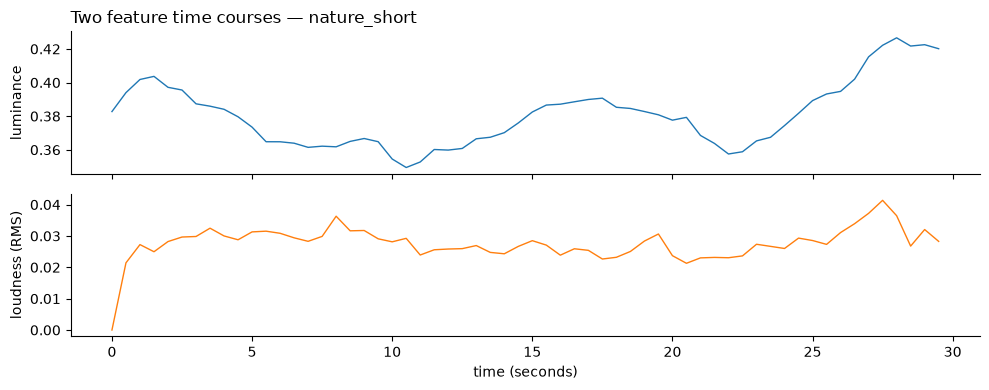

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
t_s = X.index.to_numpy()
ax[0].plot(t_s, X["visual__luminance_mean"], lw=1.0)
ax[0].set_ylabel("luminance"); ax[0].set_title("Two feature time courses — nature_short", loc="left")
ax[1].plot(t_s, X["audio__rms_mean"], lw=1.0, color="C1")
ax[1].set_ylabel("loudness (RMS)"); ax[1].set_xlabel("time (seconds)")
for a in ax:
    a.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

**Audio-only clips** (like music) yield audio features only — no visual columns —
automatically. Nothing special to configure.

In [5]:
Xm = by_name["music_only"]
families = sorted({c.split("__")[0] for c in Xm.columns})
print("music_only:", Xm.shape, "-> feature families:", families)

music_only: (38, 18) -> feature families: ['audio']


## 3. Relate features to a recorded signal — `encode`

This is the workflow behind the core research question: *which features track a
separately recorded signal, and at what delay?* A recorded response often **trails**
the stimulus by a fixed lag (an fMRI hemodynamic response peaks a few seconds
later), so `encode` **scans lags** and fits a cross-validated ridge model.

As a check on the machinery, we build a mock "recording" from the clip's own
loudness **delayed by one bin**, add noise, and hand it to `encode` blind. It should
find the delay (lag 1) and lean on the feature the signal was built from
(`audio__rms_mean`). This is a plumbing check on public footage — not a claim about
real brain data.

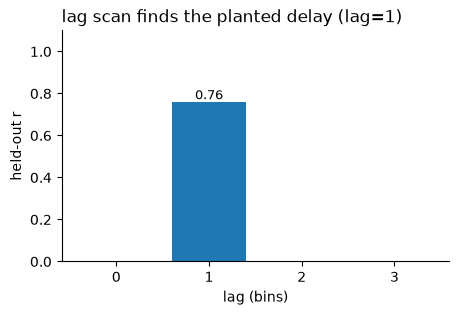

top features the model leans on:
  +1.177  audio__rms_mean
  -0.337  audio__spectral_flux_max
  -0.319  audio__pitch_f0_mean


In [6]:
from affectlens import encoding

def z(s): return (s - s.mean()) / (s.std() + 1e-9)

rng = np.random.default_rng(7)
drive = z(X["audio__rms_mean"]).to_numpy()
signal = np.roll(drive, 1); signal[0] = 0.0          # trails the stimulus by 1 bin
signal = signal + rng.normal(0, 0.25, len(signal))    # + noise

lags = [0, 1, 2, 3]
rs = [encoding.encode_signal(X, signal, lag_bins=lag).r for lag in lags]
best = int(np.argmax(rs))
enc = encoding.encode_signal(X, signal, lag_bins=best)

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar([str(l) for l in lags], rs,
              color=["0.8" if l != best else "C0" for l in lags])
ax.bar_label(bars, fmt="%.2f", fontsize=9)
ax.set_xlabel("lag (bins)"); ax.set_ylabel("held-out r"); ax.set_ylim(0, 1.1)
ax.set_title(f"lag scan finds the planted delay (lag={best})", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

print("top features the model leans on:")
for name, w in enc.weights[:3]:
    print(f"  {w:+.3f}  {name}")

## 4. Bring your own signal

To relate features to **your** recording (an EEG band envelope, an fMRI ROI time
course, pupil size, heart rate), you need a CSV / array with a **time** column and a
**value** column. Two rules:

- timestamps in **seconds relative to clip onset**, and
- `interval_s` **matches the feature bin width** you extracted with.

`encoding.bin_signal(...)` resamples your signal onto the feature bins; then
`encode_signal(X, signal, lag_bins=...)` does the rest. To model a whole run of
clips, concatenate the per-clip feature matrices and the signal in the same bin
order. Below we stand in a fabricated `(times, values)` array for a real recording.

In [7]:
# Stand-in for your recording: (times_seconds, values). Replace with a real CSV:
#   sig = pd.read_csv("my_signal.csv"); times, values = sig["t"].values, sig["y"].values
rng2 = np.random.default_rng(1)
times = X.index.to_numpy() + 0.25                     # sampled ~mid-bin
values = z(X["audio__rms_mean"]).to_numpy() + rng2.normal(0, 0.4, len(X))  # a noisy "recording"

signal_on_bins = encoding.bin_signal(times, values, X.index.to_numpy(), interval_s=0.5)
result = encoding.encode_signal(X, signal_on_bins, lag_bins=0)             # contemporaneous here
print(f"held-out r = {result.r:.3f}  (r2 = {result.r2:.3f})")
print("top feature:", result.weights[0])

held-out r = 0.522  (r2 = 0.211)
top feature: ('audio__rms_mean', 0.44092983401937463)


## 5. Predict human ratings — `baseline` (optional)

If instead of a signal you have **continuous behavioral ratings** (energy, arousal,
valence, whatever your raters scored), the baseline scores how well clip content
predicts each one, with leave-one-clip-out cross-validation. Here we run it on a
built-in synthetic dataset so it works with no files; point `pipeline.run` at your
own clips + ratings CSV to use real data.

In [8]:
from affectlens.synthetic import build_synthetic_dataset

with build_synthetic_dataset(n_clips=3) as (clips_dir, ratings_csv):
    per_clip, result = pipeline.run(clips_dir, ratings_csv)

result.to_frame().round(3)   # per-rated-dimension held-out Pearson r / R2

,rated_feature,pearson_r,r2,n
0,arousal,0.851,0.719,15
1,energy,0.793,0.620,15
2,brightness,0.676,0.430,15


## The same steps from the command line

Everything above has a one-line CLI equivalent (run `affectlens <command> --help`
for the options):

| Notebook step | Command |
| --- | --- |
| 1. Inventory | `affectlens inventory --clips CLIPS` |
| 2. Extract | `affectlens extract --clips CLIPS --out out/ --interval 2.0` |
| 3/4. Encode | `affectlens encode --features out/CLIP__features.csv --signal signal.csv --lags 0,1,2` |
| 5. Baseline | `affectlens baseline --clips CLIPS --ratings ratings.csv` |
| smoke test | `affectlens selftest` |

That's the whole tool: clips in → feature time courses out → predict ratings or
explain a recorded signal.